# Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
import sys
import os
sys.path.append(os.path.abspath("..")) 
from complex_granger_analysis import tests as CGA

# Loading simple PID with faults example

In [8]:
#Załaduj dane
dane=pd.read_csv("PID_fault1.csv",sep=";",index_col='Unnamed: 0')
dane2=pd.read_csv("PID_fault2.csv",sep=";",index_col='Unnamed: 0')
data_df = pd.concat([dane,dane2], ignore_index=True)

In [9]:
dane['f2']=0
dane2['f1']=0

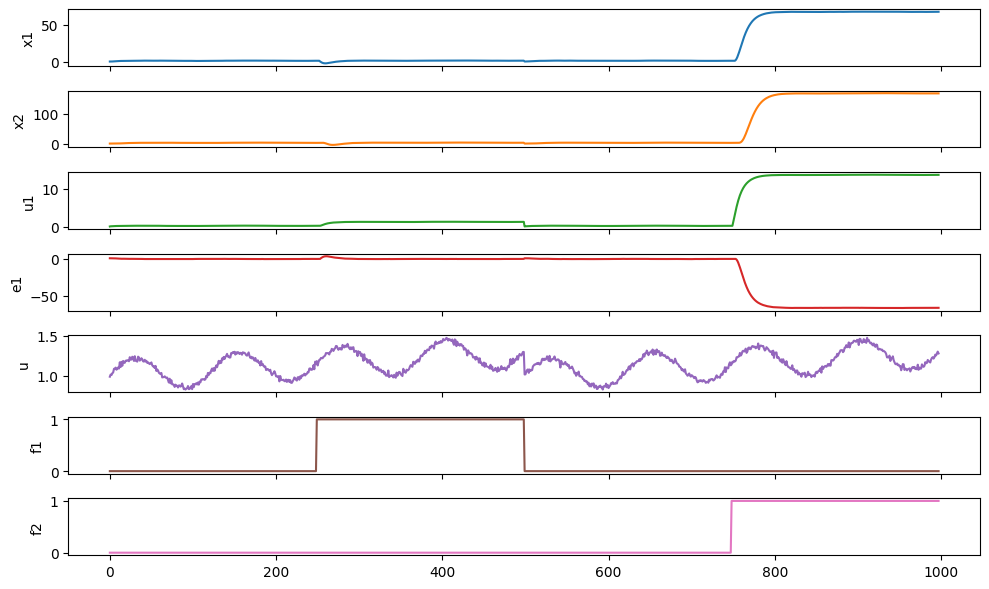

In [10]:
fig,ax = plt.subplots(len(data_df.columns), figsize=(10,6), sharex=True)
plot_cols = data_df.columns
data_df[plot_cols].plot(subplots=True, legend=False, ax=ax)
for a in range(len(ax)): 
    ax[a].set_ylabel(plot_cols[a])
ax[-1].set_xlabel('')
plt.tight_layout()
#plt.show()
plt.savefig('Ex5.svg', format='svg')

# Classical Grangera Analysis

In [11]:
CGA.grangers_causation_matrix(data_df.copy(),test="ssr_ftest")

AttributeError: module 'complex_granger_analysis.tests' has no attribute 'grangers_causation_matrix'

# Multivariable Grangera Analisys

## Scikit-learn (Newton gradient method)

It is better to give list of tables, because class can better handle table conections without creating transition zone that would create false causalities.

In [ ]:
GCskit=CGA.SparseConstrainedMVGC()
GCskit.fit([dane,dane2])
GCskit.results.result()
#25.9
#17.9

THE MODEL DID NOT CONVERGE


,x1,x2,u1,e1,u,f1,f2
x1,1,1,1,1,1,1,1
x2,0,1,1,0,1,1,0
u1,0,0,1,0,0,0,1
e1,1,0,0,1,1,0,0
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1


## Tensorflow (gradient descend with optimizer)

Optimizer can be changed as parameter of class constructor. Initial optimizer is Adam

In [ ]:
GCANN=CGA.TFNeuralSparseConstrainedMVGC()
GCANN.fit([dane,dane2])
GCANN.results.result()
# 4 44.7
# 3 11.9

/home/janek/miniconda3/envs/tf/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/janek/miniconda3/envs/tf/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
2026-02-07 23:01:29.962563: I external/local_xla/xla/service/service.cc:163] XLA service 0x74b89c0694a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-07 23:01:29.962604: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-02-07 23:01:29.979323: I tensorflow/compiler/ml

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,1,0,1,0
x2,0,1,0,0,0,0,0
u1,0,0,1,0,0,0,1
e1,1,0,0,1,0,0,0
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1


## Pytorch (gradient descend with optimizer)

Optimizer can be changed as parameter of class constructor. Initial optimizer is Adam

In [ ]:
GCANN2=CGA.PTNeuralSparseConstrainedMVGC()
GCANN2.fit(data=[dane,dane2])
GCANN2.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,0,1,0,0
x2,1,1,0,0,0,0,0
u1,0,0,1,0,0,0,1
e1,1,0,0,1,1,0,0
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1


# Features presentation

## Limiting the analysed varible/signals

### Limiting signals which might be the cause

Comment: All given columns are used for predictions, but only chosen are analysed

In [ ]:
GCANN2=CGA.PTNeuralSparseConstrainedMVGC()
GCANN2.fit(data=[dane,dane2],effects=['x1','x2','u1'],causes=['f1','f2'])
GCANN2.results.result()

,f1,f2
x1,1,0
x2,0,0
u1,0,1
e1,0,0
u,0,0
f1,1,0
f2,0,1


### Limitin signals which are checked for being affected

In [ ]:
GCANN2=CGA.PTNeuralSparseConstrainedMVGC()
GCANN2.fit(data=[dane,dane2],effects=['x1','x2','u1'])
GCANN2.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,1,0,1,0
x2,0,1,0,0,0,0,0
u1,0,0,1,0,0,0,1


## Lag control 

### Change automatic lag search range

In [ ]:
GCANN2=CGA.PTNeuralSparseConstrainedMVGC(min_lag=2,max_lag=10)
GCANN2.fit(data=[dane,dane2])
GCANN2.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,1,1,1,0,1,0
x2,0,1,1,1,0,1,0
u1,0,0,1,0,0,0,1
e1,1,0,1,1,0,0,0
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1


In [12]:
GCANN2.lag_order

{'min': array([1, 1, 1, 1, 1, 1, 1]), 'max': array([2, 2, 2, 2, 2, 2, 2])}

### For lag range for all variable

In [ ]:
GCANN2=CGA.PTNeuralSparseConstrainedMVGC()
GCANN2.fit(data=[dane,dane2],base_lag=4)
GCANN2.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,1,1,1,0,1,1
x2,1,1,1,1,0,0,0
u1,0,0,1,0,0,0,1
e1,1,0,1,1,1,1,1
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1


### Change lag range for chosen variable

In [ ]:
GCANN2=CGA.PTNeuralSparseConstrainedMVGC()
GCANN2.fit(data=[dane,dane2],custom_lag={'x2':[3,#lowest lag
                                               4 #highest lag
                                               ]})
GCANN2.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,1,0,1,0
x2,1,1,1,1,0,1,0
u1,0,0,1,0,0,0,1
e1,1,0,0,1,0,0,0
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1


### Add zero lag to analysis

Comment: zero lag data is forcefully omitted in autoregression

In [ ]:
GCANN2=CGA.PTNeuralSparseConstrainedMVGC(use_zero_lag=True)
GCANN2.fit(data=[dane,dane2])
GCANN2.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,1,0,1,0
x2,0,1,0,0,0,0,0
u1,0,0,1,0,0,0,1
e1,1,0,0,1,0,0,0
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1


In [18]:
GCANN2.lag_order

{'min': array([0, 0, 0, 0, 0, 0, 0]), 'max': array([1, 1, 1, 1, 1, 1, 1])}

## Sparsity

### L1 regularizetion with given value

In [ ]:
GCskit2=CGA.SparseConstrainedMVGC(sparse=1e-4)
GCskit2.fit(data=[dane,dane2])
GCskit2.results.result()

THE MODEL DID NOT CONVERGE


,x1,x2,u1,e1,u,f1,f2
x1,1,1,1,1,1,1,1
x2,0,1,1,0,1,1,0
u1,0,0,1,0,0,0,1
e1,1,0,0,1,1,0,0
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1


### L1 regularizetion with automatically chosen value

In [ ]:
GCskit2=CGA.SparseConstrainedMVGC(sparse=-1,sparse_fit_epochs = 100)
GCskit2.fit(data=[dane,dane2])
GCskit2.results.result()

THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE
THE MODEL DID NOT CONVERGE


,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,1,0,1,1
x2,0,1,0,0,0,0,0
u1,0,0,1,0,0,0,1
e1,1,0,0,1,0,0,1
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,1,0,0,1,0


In [32]:
GCskit2.sparse

0.01

### L1 regularizetion with penalty for greater lags 

Indiferent to lag

In [ ]:
GCskit2=CGA.SparseConstrainedMVGC(sparse=1e-2)
GCskit2.fit(data=[dane,dane2],base_lag=3)
GCskit2.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,1,0,1,0
x2,0,1,0,0,0,0,0
u1,0,0,1,0,1,1,1
e1,1,0,1,1,0,1,1
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,1,0,0,1,0


With lag penalty

For Tensorflow and Torch it is implemented as regularizer, which is an anttribute of test class

In [ ]:
# Cost change with lags table
CGA.MTCLR.cycle=np.linspace(1, 3.0, 20)

GCskit2=CGA.SparseConstrainedMVGC(sparse=1e-2,cycle_lasso=True)
GCskit2.fit(data=[dane,dane2],base_lag=3)
GCskit2.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,1,0,1,0
x2,0,1,0,0,0,0,0
u1,0,0,1,0,1,1,1
e1,1,0,1,1,0,1,0
u,0,0,0,0,1,1,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,1,0


## Causal expert knowledge

### Force no causal relation

In [ ]:
GCskit2=CGA.SparseConstrainedMVGC()
GCskit2.fit(data=[dane,dane2],relation={('x2','e1'):0})
GCskit2.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,1,1,1,0
x2,1,1,1,0,0,1,1
u1,0,0,1,0,0,0,1
e1,1,0,0,1,1,0,0
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1


### Encourage causal relation

In [ ]:
GC=CGA.PTNeuralSparseConstrainedMVGC()
GC.fit(data=[dane,dane2],relation={('x2','x1'):0.1})
GC.results.result()

,x1,x2,u1,e1,u,f1,f2
x1,1,0,1,1,0,1,0
x2,0,1,1,1,0,0,0
u1,0,0,1,0,0,0,1
e1,1,0,0,1,0,0,0
u,0,0,0,0,1,0,0
f1,0,0,0,0,0,1,0
f2,0,0,0,0,0,0,1
